In [1]:
from cytof.problem import CytofProblem
from dmm.config_options import Conf
from dmm.petab_subproblem import load_petab
from dmm.pretraining import (
    generate_per_sample_pretraining_problems,
)
from dmm.training_helper_funcs import Chi2Objective
from util import load_petab_base_files

conf = Conf(
    model='EGFR_MAPK__logobs',
    data='dream_cytof',
    sample='cT47D',
    threads=4
)

problem = CytofProblem(conf.model)

petab_base_importer = load_petab(
    problem=problem, dataset=conf.data, **load_petab_base_files(conf)
)

importer = generate_per_sample_pretraining_problems(
    importer=petab_base_importer,
    problem=problem,
    dataset=conf.data,
    sample=conf.sample,
)

factory = importer.create_objective_creator()
objective = Chi2Objective(factory.create_objective())
problem.apply_objective_settings(objective, n_threads=conf.threads)

pypesto_problem = importer.create_problem(
    objective=objective,
)


/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/bionetgen/main.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging
Visualization table not available. Skipping.
Compiling amici model to folder /Users/frohlif/Documents/projects/DeepMechanisticModels/cytof/amici_models/EGFR_MAPK__logobs_dream_cytof_petab.
2025-08-05 15:49:53.211 - amici.petab.pysb_import - INFO - Importing model ...
2025-08-05 15:49:54.086 - amici.petab.pysb_import - DEBUG - Adding initial assignments for dict_keys([])
2025-08-05 15:49:54.147 - amici.petab.import_helpers - WARNING - Column 'DEV_RPS6KA1_dp_S380_kcat__cT47D' used in condition table but no entity with the corresponding ID exists. Ignoring.
2025-08-05 15:49:54.150 - amici.petab.import_he

running build_ext
running AmiciBuildCMakeExtension
------------------------------ model_ext ------------------------------

==> Configuring:
$ cmake -S /Users/frohlif/Documents/projects/DeepMechanisticModels/cytof/amici_models/EGFR_MAPK__logobs_dream_cytof_petab -B /Users/frohlif/Documents/projects/DeepMechanisticModels/cytof/amici_models/EGFR_MAPK__logobs_dream_cytof_petab/build_model_ext -G Ninja -DCMAKE_MAKE_PROGRAM=/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/bin/ninja -DCMAKE_BUILD_TYPE=Release -DCMAKE_INSTALL_PREFIX:PATH=/Users/frohlif/Documents/projects/DeepMechanisticModels/cytof/amici_models/EGFR_MAPK__logobs_dream_cytof_petab/EGFR_MAPK__logobs -DCMAKE_VERBOSE_MAKEFILE=ON -DCMAKE_PREFIX_PATH=/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/amici -DAMICI_PYTHON_BUILD_EXT_ONLY=ON -DPython3_EXECUTABLE=/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/bin/python

==> Building:
$ cmake --build /Users/frohlif/Docume

In [2]:
amici_model = pypesto_problem.objective.base_objective.amici_model
amici_solver = pypesto_problem.objective.base_objective.amici_solver
edatas = pypesto_problem.objective.base_objective.edatas

In [3]:
import numpy as np
for e in edatas:
    e.setTimepoints(np.linspace(0,60,20))
    e.parameters = ()


In [4]:
edatas[0]

<Swig Object of type 'amici::ExpData *' at 0x17ba07510
  condition 'cT47D__EGF+cT47D' starting at t=0.0 with custom parameter scales, constants, pre-equilibration condition, pre-simulation condition (t=15.0) with custom constants
  20x4 time-resolved datapoints
    (36/80 measurements & 36/80 sigmas set)
  10x0 event-resolved datapoints
    (0/0 measurements & 0/0 sigmas set)
>

In [5]:
import amici


In [6]:
[p for p in amici_model.getParameterIds() if 'EGFR' in p and not p.startswith('DEV')]

['MED_EGFR_deg_kdeg',
 'MED_EGFR_dp_Y1173_kcat',
 'MED_EGFR_recycle_kcat',
 'MED_ERBB2_p_Y1248_EGFR__Y1173_p_kw',
 'MED_ERBB2_p_Y1248_iEGFR_0_kw',
 'MED_EGFR_p_Y1173_bact',
 'MED_EGFR_p_Y1173_EGF_0_kw',
 'MED_EGFR_p_Y1173_iEGFR_0_kw',
 'MED_EGFR_endo_bact',
 'MED_EGFR_endo_EGF_0_kw',
 'MED_EGFR_endo_EGFR__Y1173_p_kw',
 'MED_EGFR_endo_EGFR_kw',
 'MED_EGFR_endo_ERBB2_kw',
 'MED_EGFR_deg_kcat',
 'MED_MEK_p_S222_EGFR__Y1173_p_kw',
 'MED_ERK_p_Y204_EGFR__Y1173_p_kw',
 'MED_RPS6KA1_p_S380_EGFR__Y1173_p_kw']

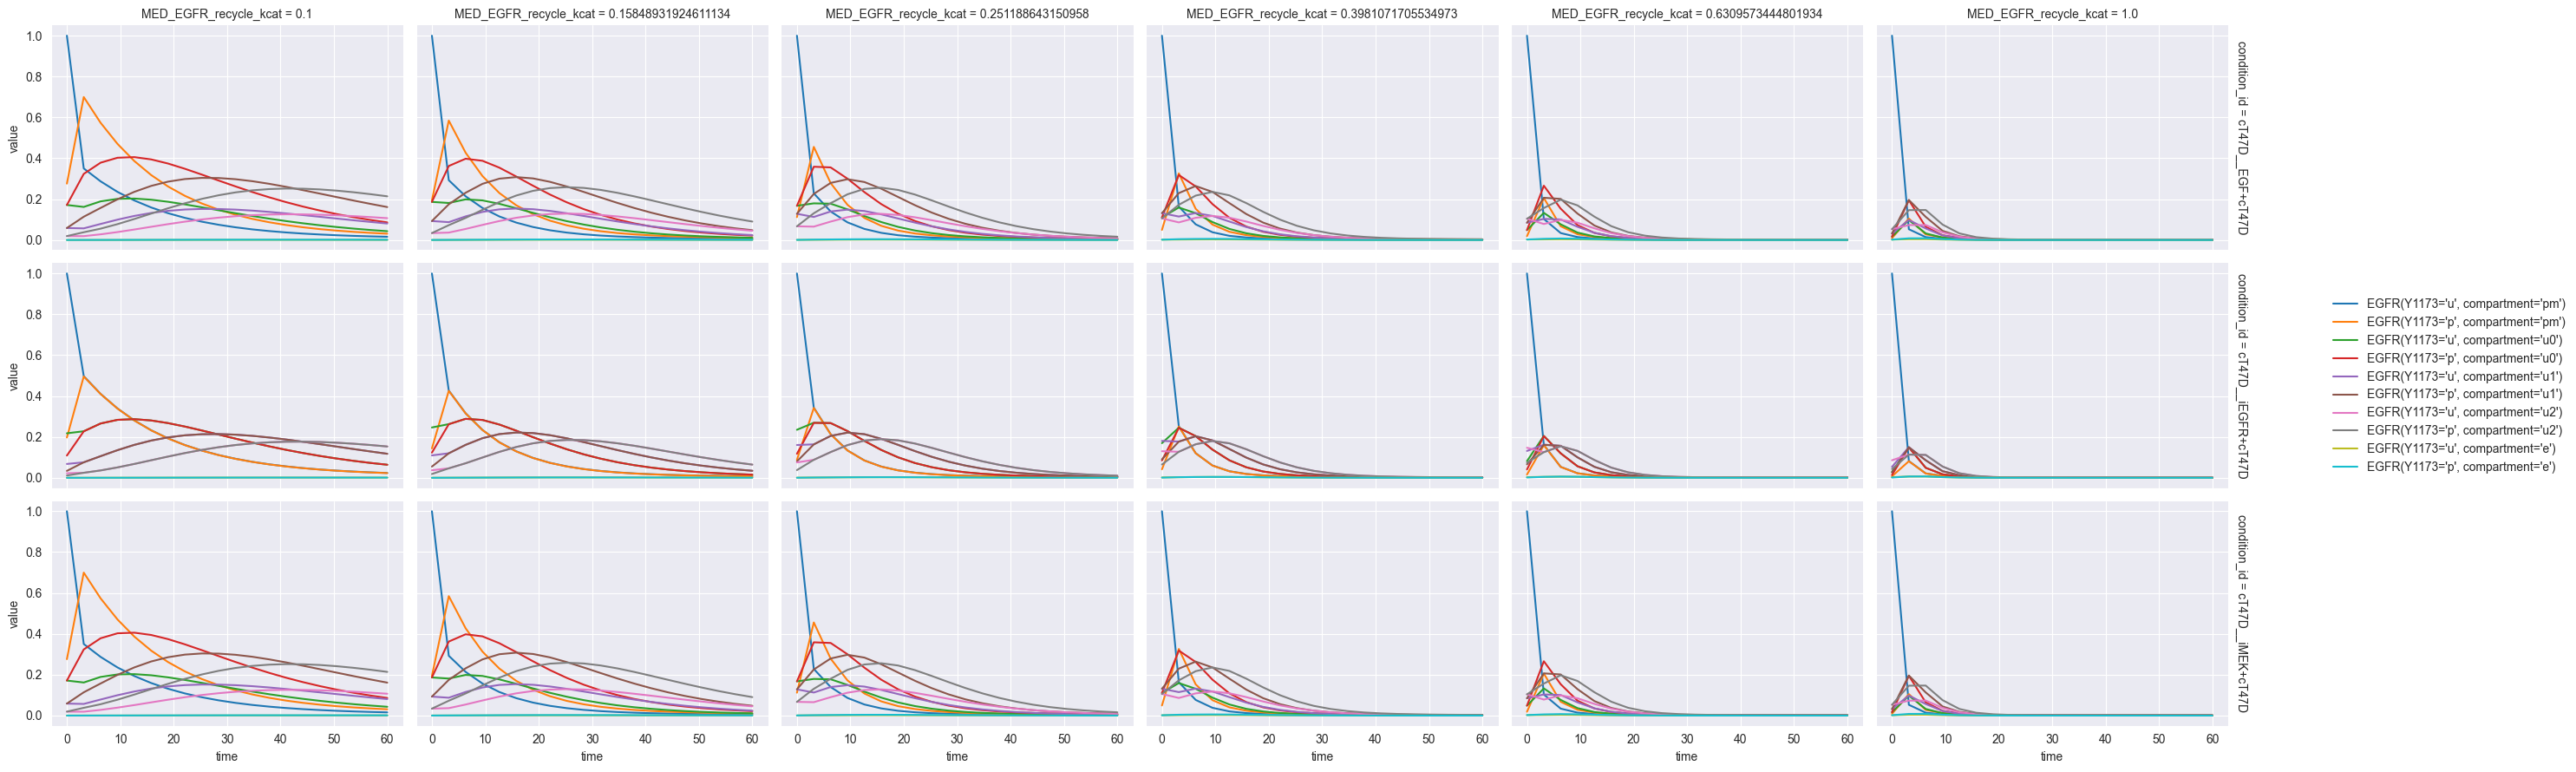

In [10]:
from amici.pandas import getSimulationStatesAsDataFrame
import pandas as pd
import seaborn as sns
pname = 'MED_EGFR_recycle_kcat'
dfs = []
for pval in np.logspace(-1,0,6):
    amici_model.setParameterById('MED_EGFR_deg_kdeg', 0.001)
    amici_model.setParameterById('MED_EGFR_deg_kcat', 10)
    amici_model.setParameterById(pname, pval)
    rdatas=amici.runAmiciSimulations(amici_model, amici_solver, edatas, num_threads=conf.threads)
    dfs.append(
        getSimulationStatesAsDataFrame(amici_model, edatas, rdatas)
    )

df = pd.melt(
    pd.concat(dfs),
    value_vars=amici_model.getStateNames(),
    id_vars=['time', 'condition_id', pname]
)
df = df[df.variable.str.startswith('EGFR')]
sns.FacetGrid(df, row='condition_id', col=pname, margin_titles=True, aspect=1.5).map_dataframe(sns.lineplot, x='time',
                                                                                               y='value',
                                                                                               hue='variable',
                                                                                               palette='tab10').add_legend()